In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
orders_df = pd.read_excel('/content/Orders.xlsx')
display(orders_df.head())

,Order ID,Order Date,CustomerName,State,City
0,B-26055,10-03-2024,Harivansh,Uttar Pradesh,Mathura
1,B-25993,03-02-2024,Madhav,Delhi,Delhi
2,B-25973,24-01-2024,Madan Mohan,Uttar Pradesh,Mathura
3,B-25923,27-12-2024,Gopal,Maharashtra,Mumbai
4,B-25757,21-08-2024,Vishakha,Madhya Pradesh,Indore


In [ ]:
details_df = pd.read_excel('/content/Details.xlsx')
display(details_df.head())

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,1096,658,7,Electronics,Electronic Games,COD
1,B-26055,5729,64,14,Furniture,Chairs,EMI
2,B-25955,2927,146,8,Furniture,Bookcases,EMI
3,B-26093,2847,712,8,Electronics,Printers,Credit Card
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card


In [ ]:
merged_df = pd.merge(orders_df, details_df, on='Order ID', how='inner')
display(merged_df.head())

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-26055,10-03-2024,Harivansh,Uttar Pradesh,Mathura,5729,64,14,Furniture,Chairs,EMI
1,B-26055,10-03-2024,Harivansh,Uttar Pradesh,Mathura,671,114,9,Electronics,Phones,Credit Card
2,B-26055,10-03-2024,Harivansh,Uttar Pradesh,Mathura,443,11,1,Clothing,Saree,COD
3,B-26055,10-03-2024,Harivansh,Uttar Pradesh,Mathura,57,7,2,Clothing,Shirt,UPI
4,B-26055,10-03-2024,Harivansh,Uttar Pradesh,Mathura,227,48,5,Clothing,Stole,COD


In [ ]:
profit_by_category = merged_df.groupby('Category')['Profit'].sum().reset_index()
display(profit_by_category)

,Category,Profit
0,Clothing,48831
1,Electronics,53938
2,Furniture,35845


In [ ]:
profit_by_sub_category = merged_df.groupby(['Category', 'Sub-Category'])['Profit'].sum().reset_index()
display(profit_by_sub_category)

,Category,Sub-Category,Profit
0,Clothing,Hankerchief,7012
1,Clothing,Kurti,-1034
2,Clothing,Leggings,-986
3,Clothing,Saree,13768
4,Clothing,Shirt,5049
5,Clothing,Skirt,-1395
6,Clothing,Stole,9894
7,Clothing,T-shirt,5856
8,Clothing,Trousers,10667
9,Electronics,Accessories,10099


In [ ]:
profit_by_state = merged_df.groupby('State')['Profit'].sum().reset_index()
display(profit_by_state)

,State,Profit
0,Andhra Pradesh,2705
1,Bihar,2427
2,Delhi,9287
3,Goa,-1202
4,Gujarat,10027
5,Haryana,4453
6,Himachal Pradesh,5733
7,Jammu and Kashmir,5142
8,Karnataka,884
9,Kerala,5778


In [ ]:
top_5_states = profit_by_state.sort_values(by='Profit', ascending=False).head(5)
display(top_5_states)

,State,Profit
11,Maharashtra,32708
10,Madhya Pradesh,22465
4,Gujarat,10027
2,Delhi,9287
17,Uttar Pradesh,9254


In [ ]:
highest_profit_sub_category_per_category = profit_by_sub_category.loc[profit_by_sub_category.groupby('Category')['Profit'].idxmax()]
display(highest_profit_sub_category_per_category)

,Category,Sub-Category,Profit
3,Clothing,Saree,13768
12,Electronics,Printers,39537
13,Furniture,Bookcases,18591


In [ ]:
profit_quantity_correlation = merged_df['Profit'].corr(merged_df['Quantity'])
print(f"Correlation between Profit and Quantity: {profit_quantity_correlation:.2f}")

Correlation between Profit and Quantity: 0.06


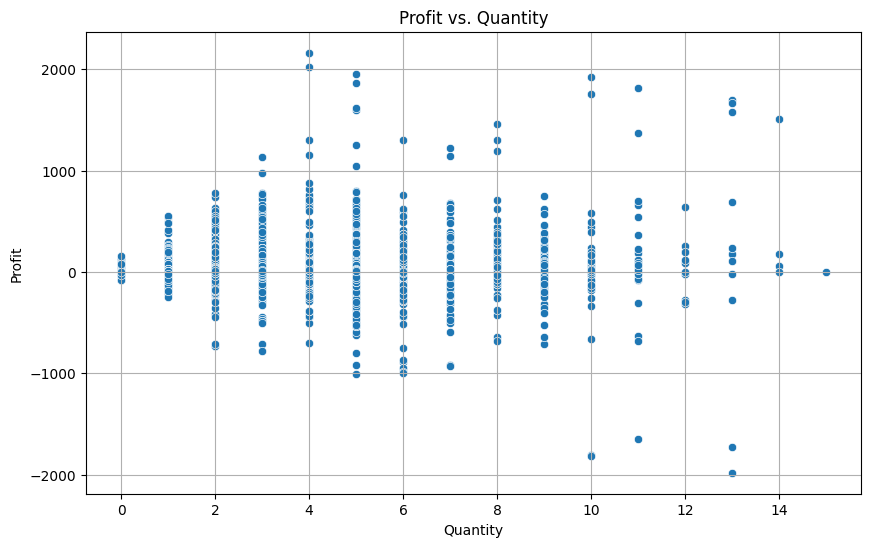

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quantity', y='Profit', data=merged_df)
plt.title('Profit vs. Quantity')
plt.xlabel('Quantity')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [ ]:
model = smf.ols('Profit ~ Quantity', data=merged_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     19.01
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.32e-05
Time:                        17:17:10   Log-Likelihood:                -39500.
No. Observations:                6000   AIC:                         7.900e+04
Df Residuals:                    5998   BIC:                         7.902e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.2661      4.084      2.024      0.0

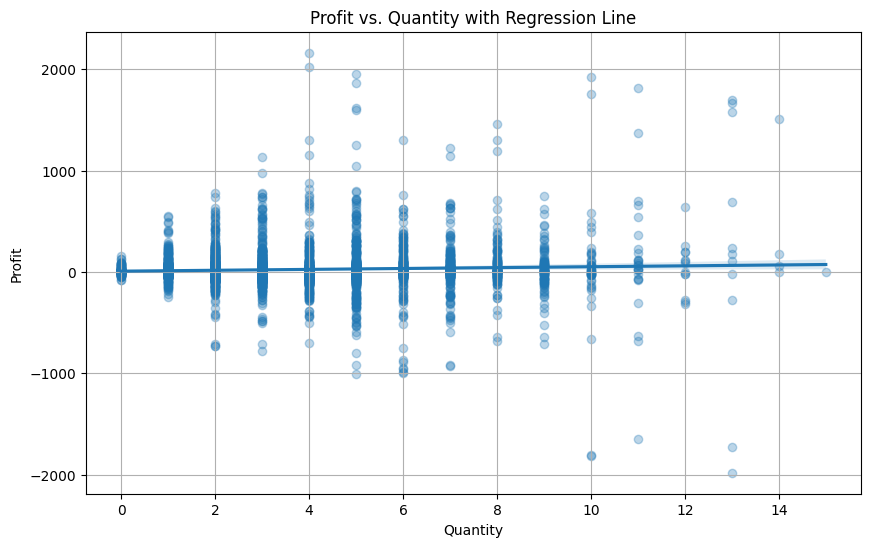

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Quantity', y='Profit', data=merged_df, scatter_kws={'alpha':0.3})
plt.title('Profit vs. Quantity with Regression Line')
plt.xlabel('Quantity')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

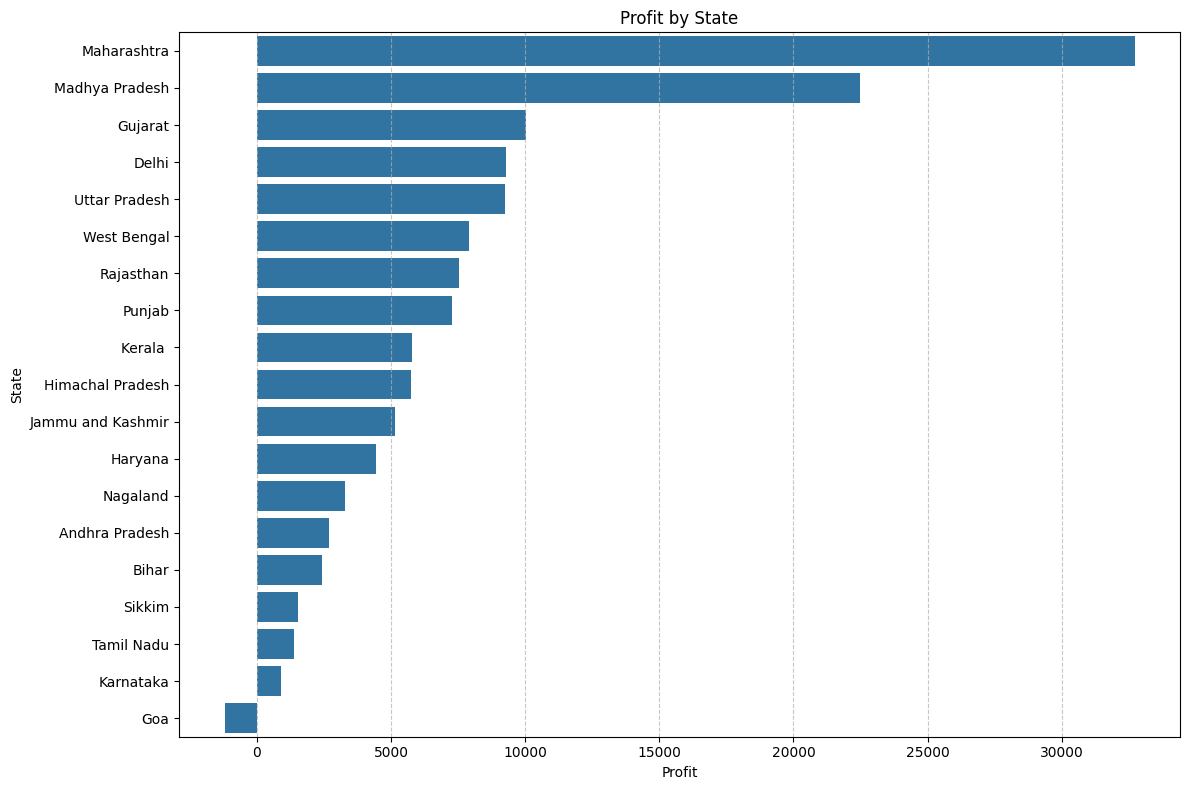

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Profit', y='State', data=profit_by_state.sort_values(by='Profit', ascending=False))
plt.title('Profit by State')
plt.xlabel('Profit')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
top_10_sub_categories = profit_by_sub_category.sort_values(by='Profit', ascending=False).head(10)
display(top_10_sub_categories)

,Category,Sub-Category,Profit
12,Electronics,Printers,39537
13,Furniture,Bookcases,18591
16,Furniture,Tables,15719
3,Clothing,Saree,13768
8,Clothing,Trousers,10667
9,Electronics,Accessories,10099
6,Clothing,Stole,9894
0,Clothing,Hankerchief,7012
7,Clothing,T-shirt,5856
4,Clothing,Shirt,5049


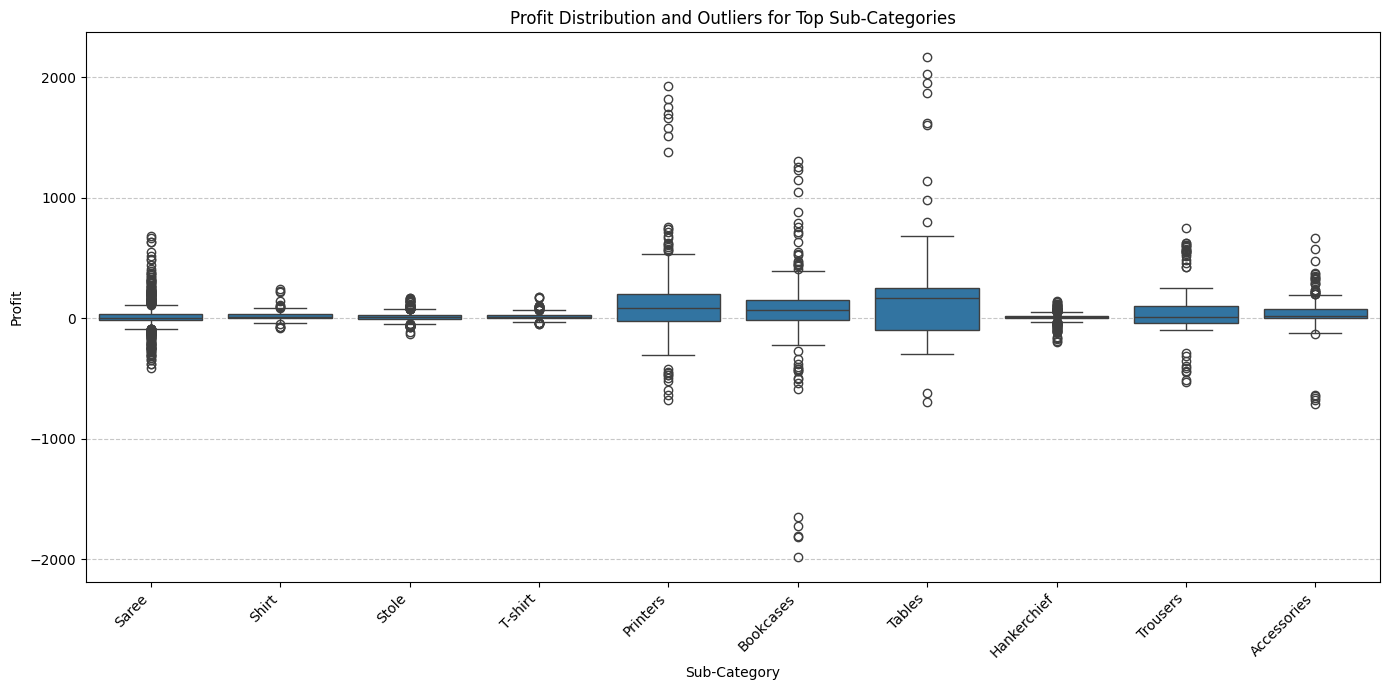

In [ ]:
top_sub_category_names = top_10_sub_categories['Sub-Category'].tolist()
filtered_df_top_sub_categories = merged_df[merged_df['Sub-Category'].isin(top_sub_category_names)]

plt.figure(figsize=(14, 7))
sns.boxplot(x='Sub-Category', y='Profit', data=filtered_df_top_sub_categories)
plt.title('Profit Distribution and Outliers for Top Sub-Categories')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
average_profit_by_category = merged_df.groupby('Category')['Profit'].mean().reset_index()
display(average_profit_by_category)

,Category,Profit
0,Clothing,12.830005
1,Electronics,43.533495
2,Furniture,37.534031


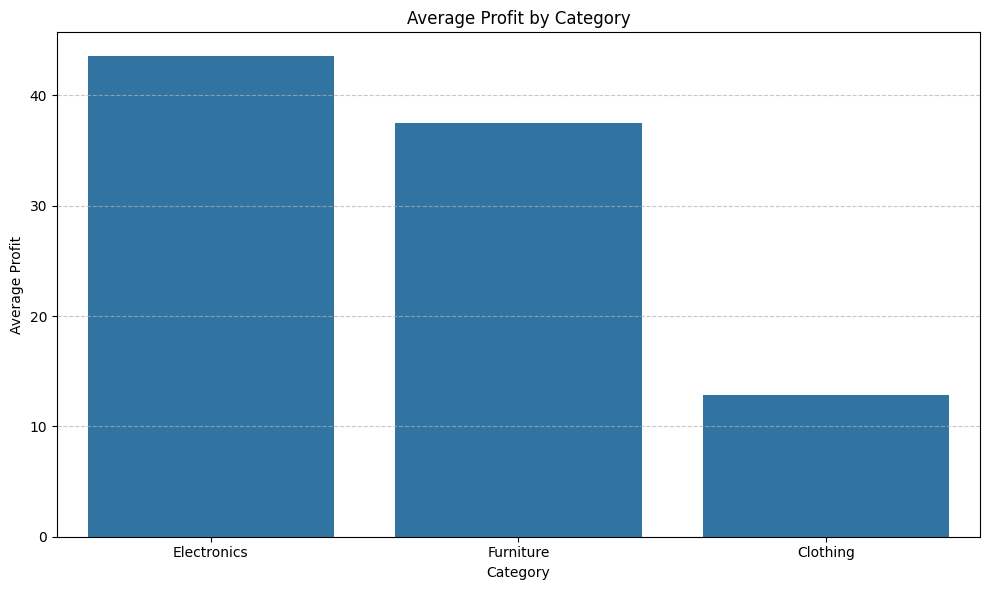

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Profit', data=average_profit_by_category.sort_values(by='Profit', ascending=False))
plt.title('Average Profit by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1398/1354891312.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




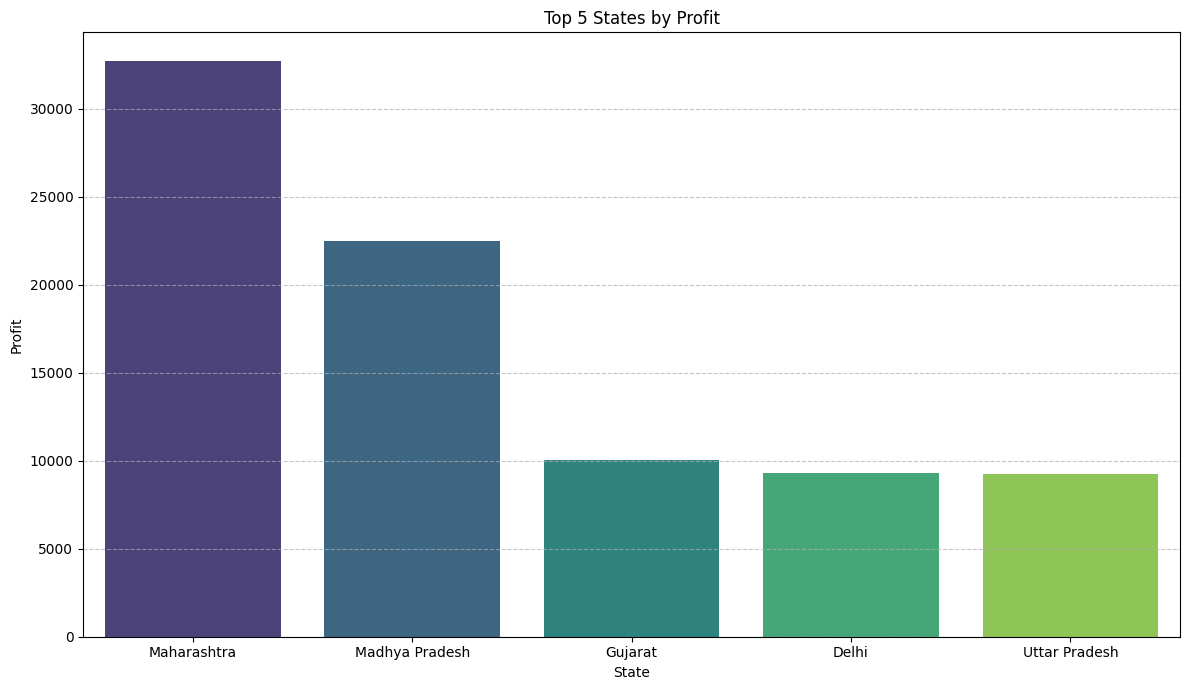

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='State', y='Profit', data=top_5_states, palette='viridis')
plt.title('Top 5 States by Profit')
plt.xlabel('State')
plt.ylabel('Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

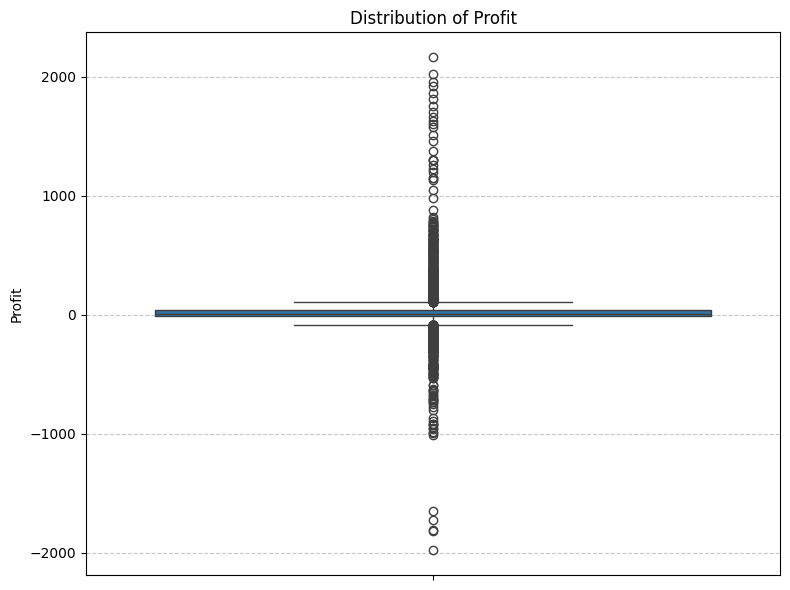

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Profit', data=merged_df)
plt.title('Distribution of Profit')
plt.ylabel('Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

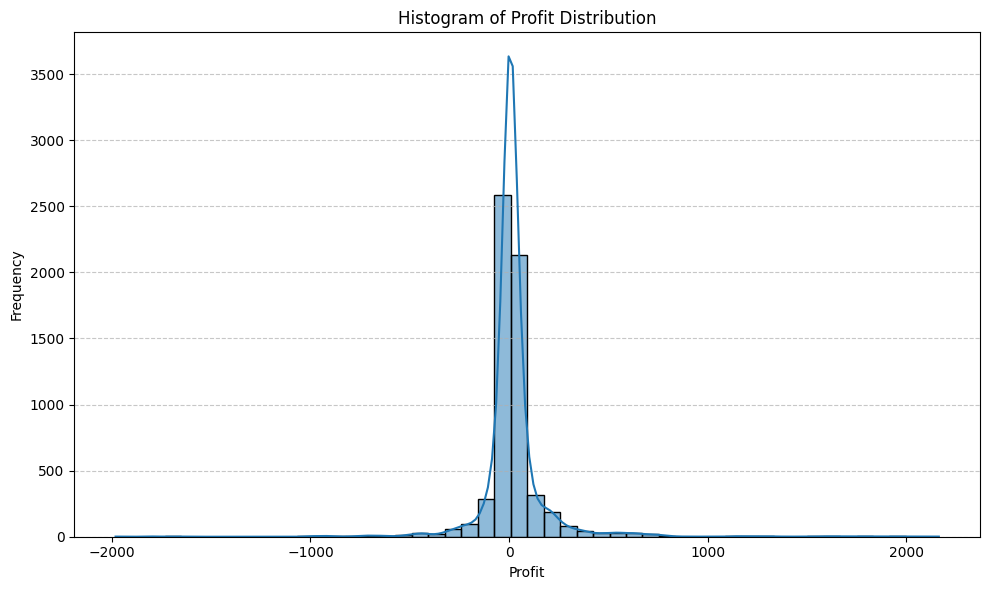

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['Profit'], kde=True, bins=50)
plt.title('Histogram of Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

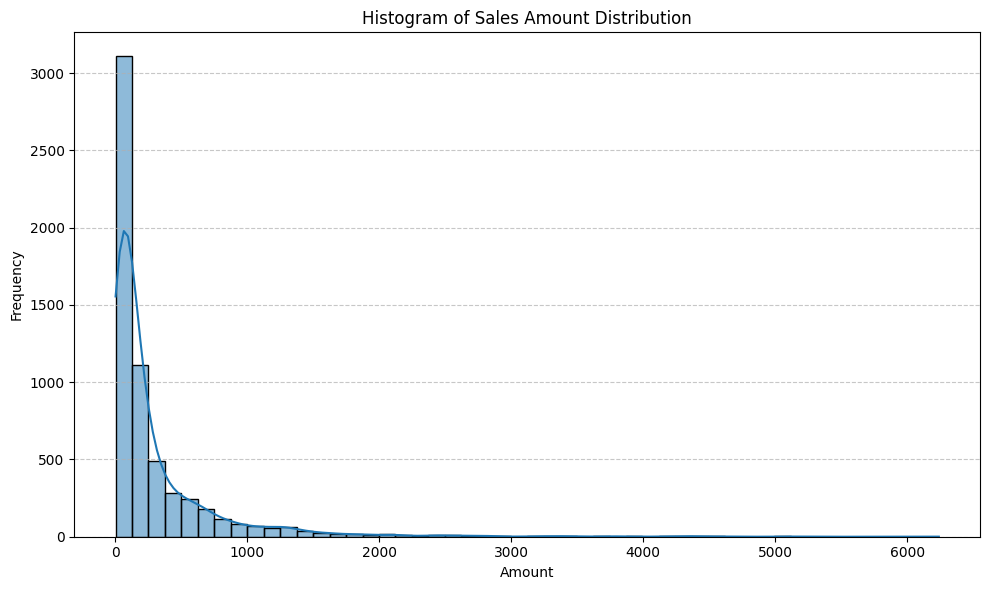

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['Amount'], kde=True, bins=50)
plt.title('Histogram of Sales Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

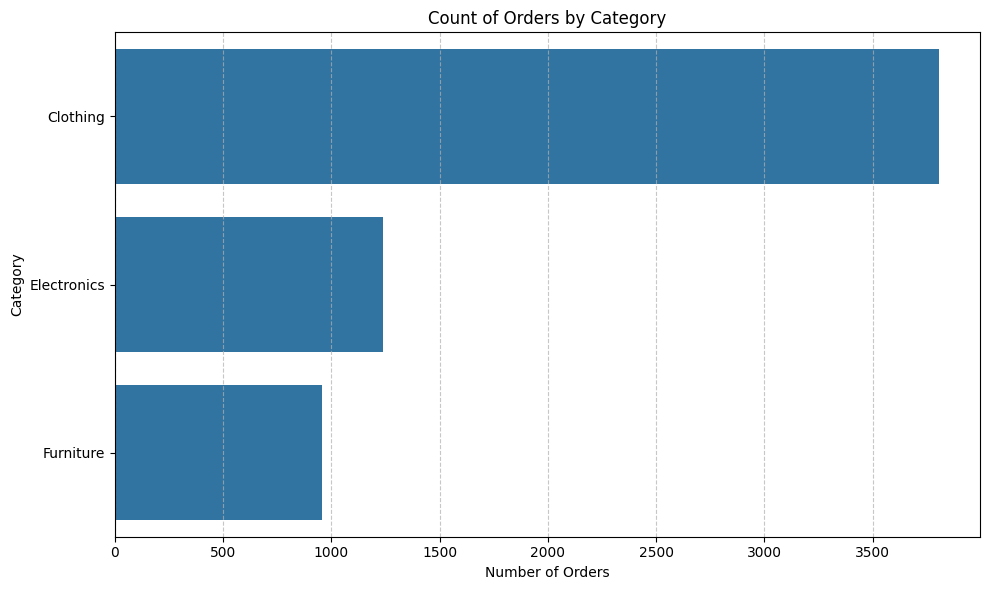

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Category', data=merged_df, order = merged_df['Category'].value_counts().index)
plt.title('Count of Orders by Category')
plt.xlabel('Number of Orders')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
average_profit_by_payment_mode = merged_df.groupby('PaymentMode')['Profit'].mean().reset_index()
display(average_profit_by_payment_mode)

,PaymentMode,Profit
0,COD,18.193203
1,Credit Card,78.653907
2,Debit Card,15.516049
3,EMI,30.480885
4,UPI,9.074319


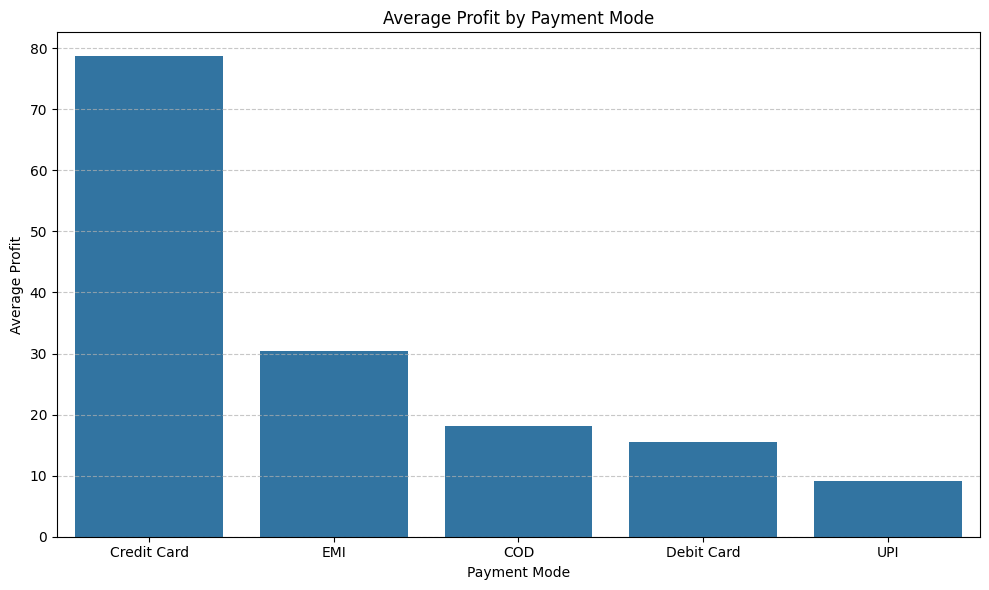

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='PaymentMode', y='Profit', data=average_profit_by_payment_mode.sort_values(by='Profit', ascending=False))
plt.title('Average Profit by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Average Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

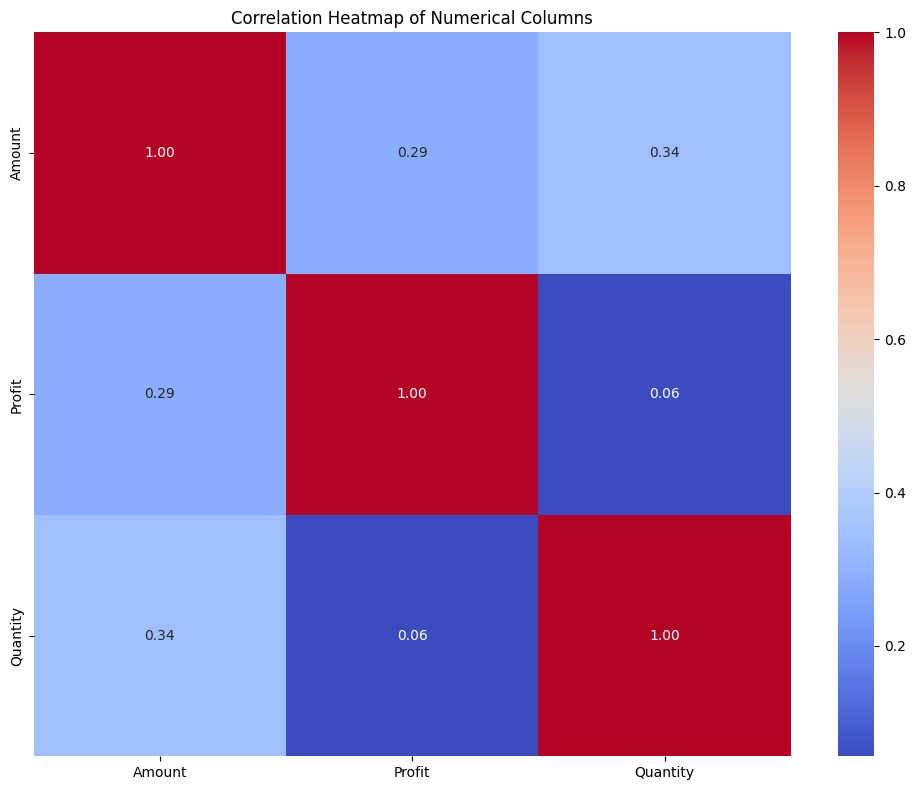

In [ ]:
numerical_cols = merged_df.select_dtypes(include=np.number).columns
correlation_matrix = merged_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.tight_layout()
plt.show()

In [ ]:
category_sales_profit = merged_df.groupby('Category').agg(
    Total_Profit=('Profit', 'sum'),
    Total_Amount=('Amount', 'sum')
).reset_index()

category_sales_profit['Profit_Margin'] = (category_sales_profit['Total_Profit'] / category_sales_profit['Total_Amount']) * 100
display(category_sales_profit)

,Category,Total_Profit,Total_Amount,Profit_Margin
0,Clothing,48831,569999,8.566857
1,Electronics,53938,689101,7.827300
2,Furniture,35845,488194,7.342368


In [ ]:
sub_category_sales_profit = merged_df.groupby(['Category', 'Sub-Category']).agg(
    Total_Profit=('Profit', 'sum'),
    Total_Amount=('Amount', 'sum')
).reset_index()

sub_category_sales_profit['Profit_Margin'] = (sub_category_sales_profit['Total_Profit'] / sub_category_sales_profit['Total_Amount']) * 100
display(sub_category_sales_profit.sort_values(by='Profit_Margin', ascending=False))

,Category,Sub-Category,Total_Profit,Total_Amount,Profit_Margin
4,Clothing,Shirt,5049,26448,19.090290
7,Clothing,T-shirt,5856,30910,18.945325
16,Furniture,Tables,15719,89037,17.654458
12,Electronics,Printers,39537,256977,15.385424
6,Clothing,Stole,9894,71019,13.931483
9,Electronics,Accessories,10099,80246,12.585051
0,Clothing,Hankerchief,7012,57897,12.111163
8,Clothing,Trousers,10667,125882,8.473809
13,Furniture,Bookcases,18591,220732,8.422431
3,Clothing,Saree,13768,228494,6.025541


In [ ]:
display(sub_category_sales_profit.sort_values(by='Profit_Margin', ascending=False).head())

,Category,Sub-Category,Total_Profit,Total_Amount,Profit_Margin
4,Clothing,Shirt,5049,26448,19.090290
7,Clothing,T-shirt,5856,30910,18.945325
16,Furniture,Tables,15719,89037,17.654458
12,Electronics,Printers,39537,256977,15.385424
6,Clothing,Stole,9894,71019,13.931483


In [ ]:
display(sub_category_sales_profit.sort_values(by='Profit_Margin', ascending=True).head())

,Category,Sub-Category,Total_Profit,Total_Amount,Profit_Margin
5,Clothing,Skirt,-1395,7275,-19.175258
2,Clothing,Leggings,-986,8572,-11.502566
1,Clothing,Kurti,-1034,13502,-7.658125
15,Furniture,Furnishings,-2892,53697,-5.385776
10,Electronics,Electronic Games,230,164727,0.139625


/tmp/ipykernel_1398/1394643785.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




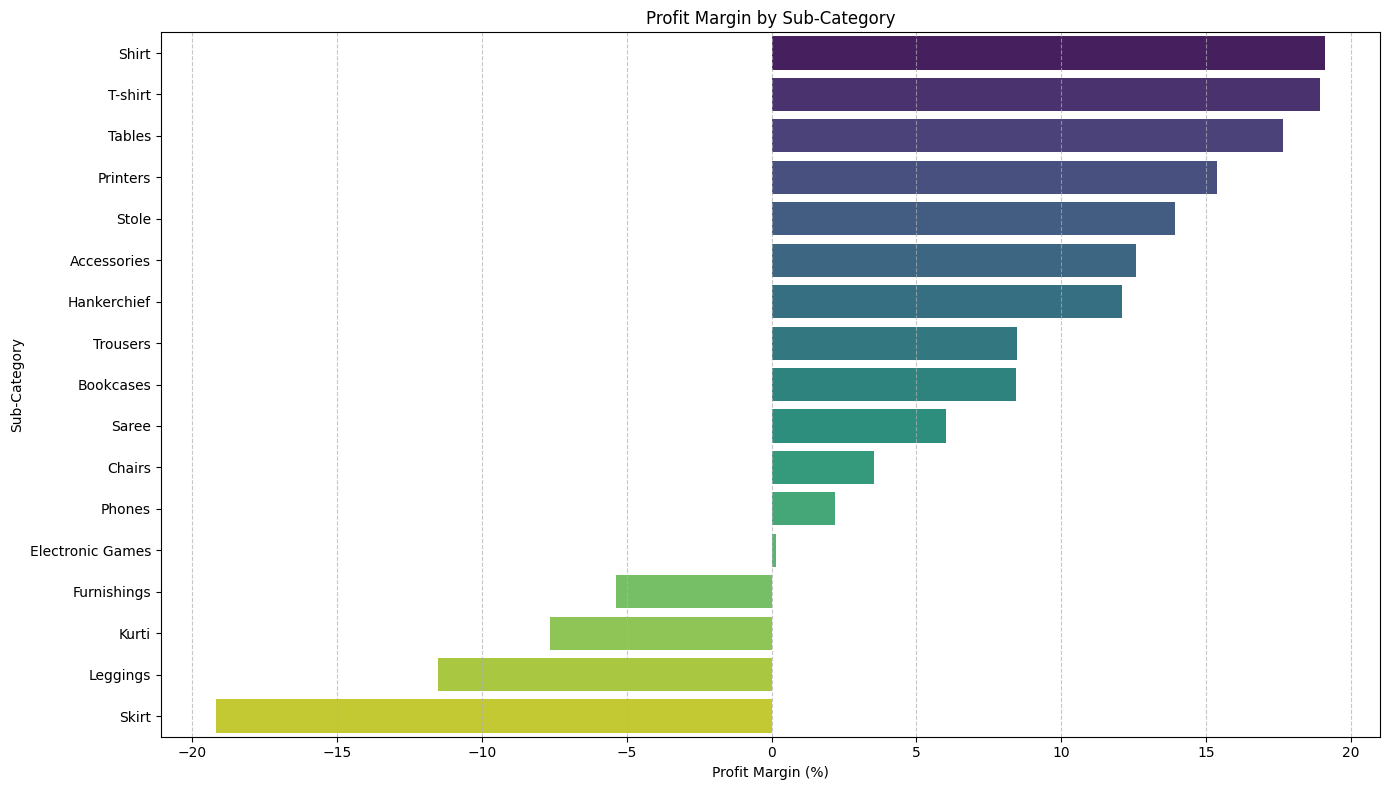

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Profit_Margin', y='Sub-Category', data=sub_category_sales_profit.sort_values(by='Profit_Margin', ascending=False), palette='viridis')
plt.title('Profit Margin by Sub-Category')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Sub-Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

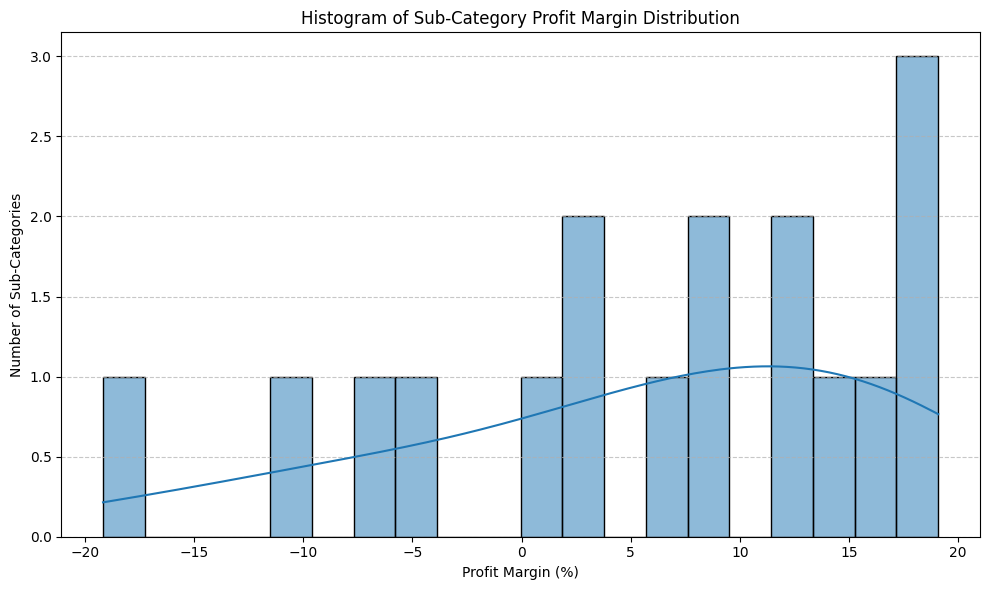

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(sub_category_sales_profit['Profit_Margin'], kde=True, bins=20)
plt.title('Histogram of Sub-Category Profit Margin Distribution')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Number of Sub-Categories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

In [ ]:
fig_state_profit = px.treemap(
    profit_by_state,
    path=['State'],
    values='Profit',
    title='Total Profit by State',
    color='Profit',
    color_continuous_scale='viridis'
)
fig_state_profit.show()

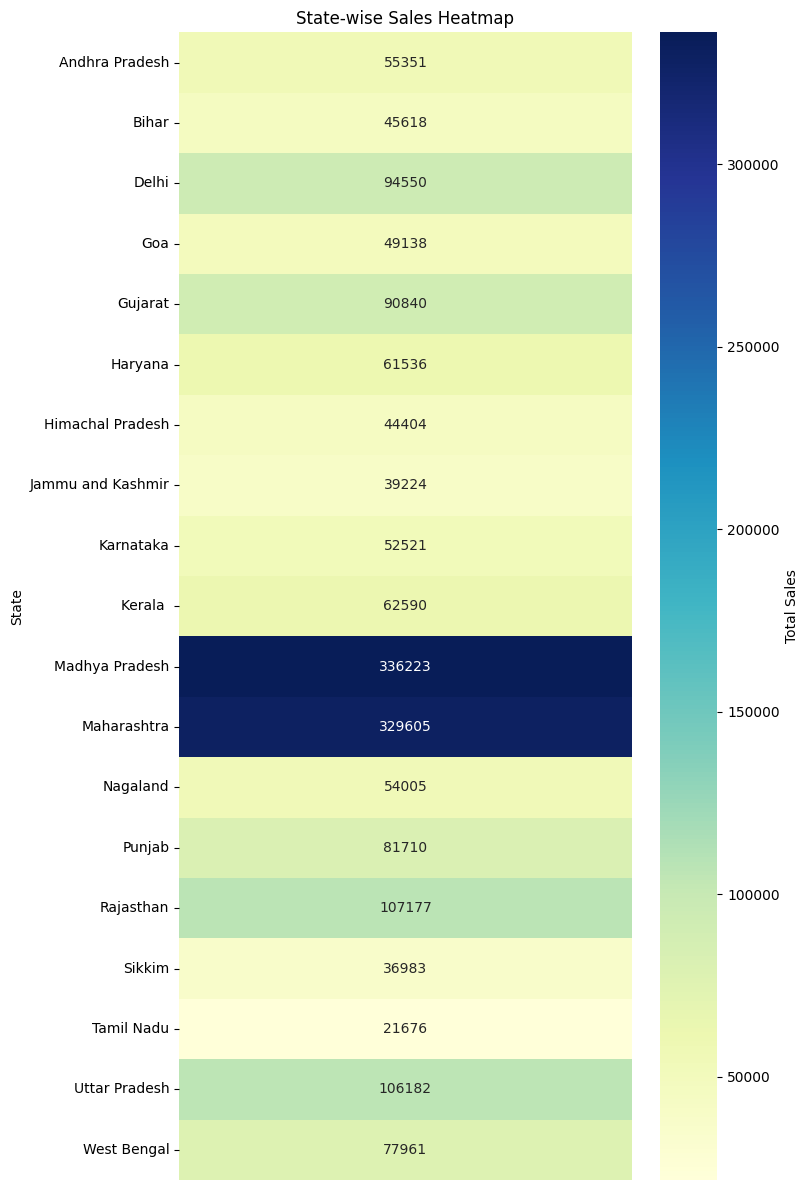

In [ ]:
sales_by_state = merged_df.groupby('State')['Amount'].sum().reset_index()

plt.figure(figsize=(8, 12))
sns.heatmap(sales_by_state.set_index('State'), annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Total Sales'})
plt.title('State-wise Sales Heatmap')
plt.ylabel('State')
plt.xticks([]) # Hide x-axis ticks as there's only one column
plt.tight_layout()
plt.show()

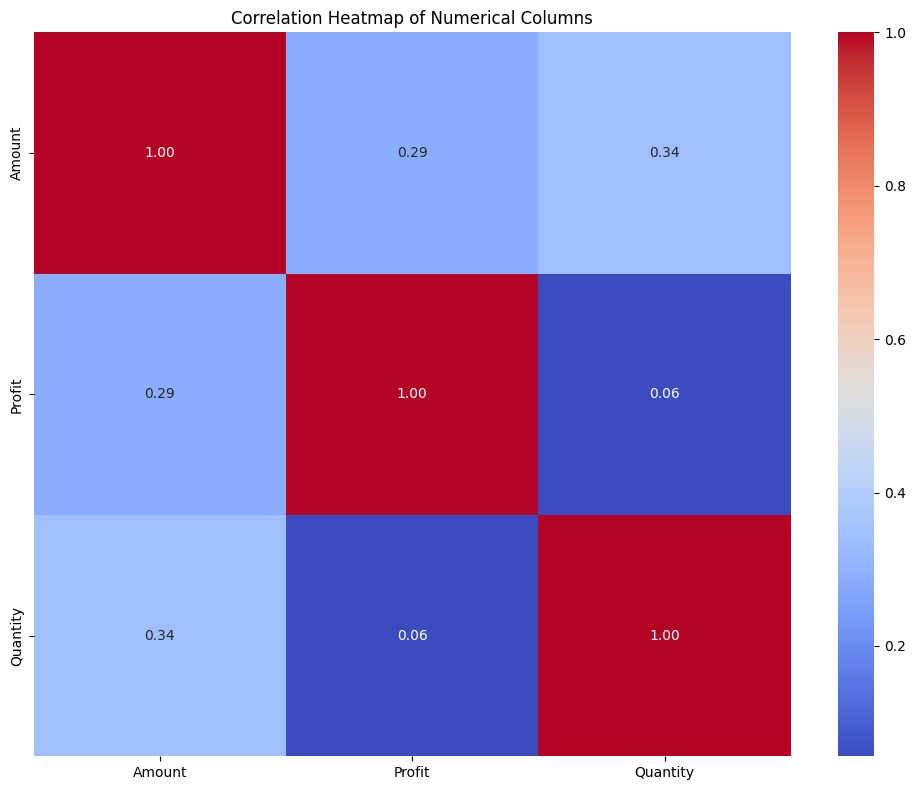

In [ ]:
numerical_cols = merged_df.select_dtypes(include=np.number).columns
correlation_matrix = merged_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.tight_layout()
plt.show()

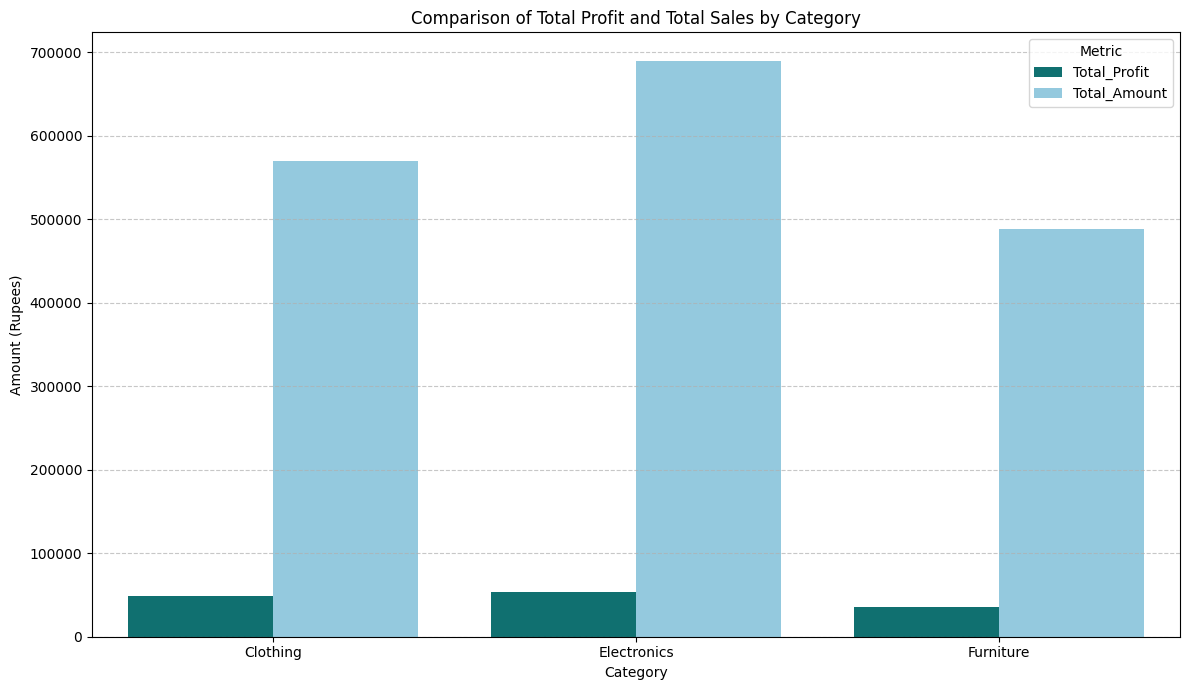

In [ ]:
category_profit_sales_melted = category_sales_profit.melt(id_vars='Category', value_vars=['Total_Profit', 'Total_Amount'], var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 7))
sns.barplot(x='Category', y='Value', hue='Metric', data=category_profit_sales_melted, palette={'Total_Profit': 'teal', 'Total_Amount': 'skyblue'})
plt.title('Comparison of Total Profit and Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Amount (Rupees)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

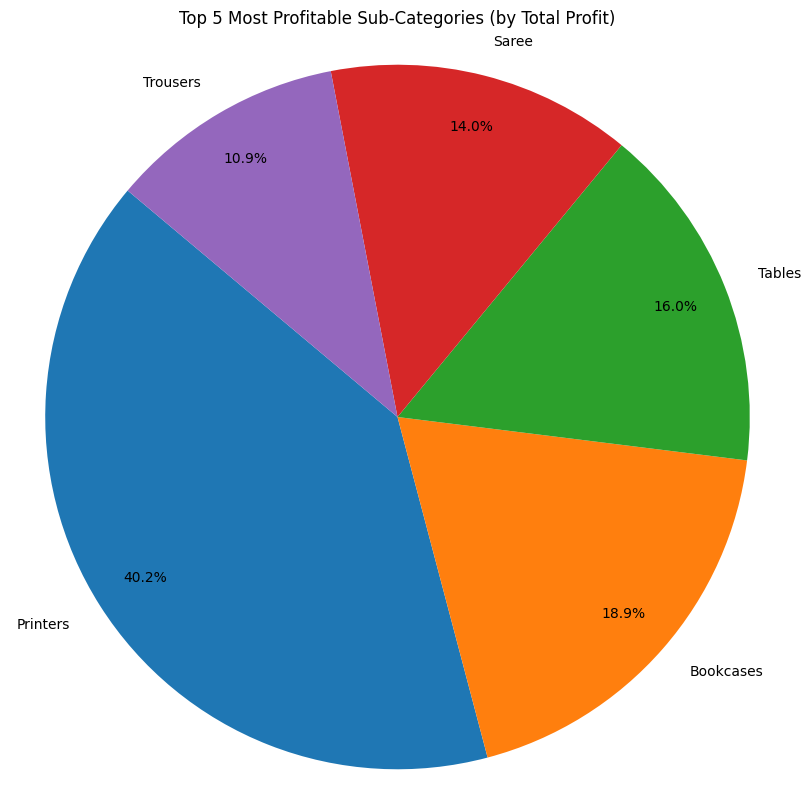

In [ ]:
top_5_sub_categories = profit_by_sub_category.sort_values(by='Profit', ascending=False).head(5)

plt.figure(figsize=(10, 10))
plt.pie(top_5_sub_categories['Profit'], labels=top_5_sub_categories['Sub-Category'], autopct='%1.1f%%', startangle=140, pctdistance=0.85)
plt.title('Top 5 Most Profitable Sub-Categories (by Total Profit)')
plt.axis('equal')
plt.show()